In [1]:
import numpy as  np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import sqlite3
import plotly.express as px

In [2]:
# import dataset

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/competitions/home-credit-default-risk/sample_submission.csv
/kaggle/input/competitions/home-credit-default-risk/bureau_balance.csv
/kaggle/input/competitions/home-credit-default-risk/POS_CASH_balance.csv
/kaggle/input/competitions/home-credit-default-risk/application_train.csv
/kaggle/input/competitions/home-credit-default-risk/HomeCredit_columns_description.csv
/kaggle/input/competitions/home-credit-default-risk/application_test.csv
/kaggle/input/competitions/home-credit-default-risk/previous_application.csv
/kaggle/input/competitions/home-credit-default-risk/credit_card_balance.csv
/kaggle/input/competitions/home-credit-default-risk/installments_payments.csv
/kaggle/input/competitions/home-credit-default-risk/bureau.csv


In [3]:
application_train = pd.read_csv("/kaggle/input/competitions/home-credit-default-risk/application_train.csv")
prev_application = pd.read_csv("/kaggle/input/competitions/home-credit-default-risk/previous_application.csv")

In [4]:
print(f"application_train\t: {application_train.shape}")
print(f"prev_application\t: {prev_application.shape}")

application_train	: (307511, 122)
prev_application	: (1670214, 37)


In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_seq_items', None)

In [6]:
application_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [7]:
prev_application.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,1,0.0,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
application_train.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE',
       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE',
       'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE',
       'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS',
       'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY',
       'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
       'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
       'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
       'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY',
       'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'APART

In [9]:
prev_application.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY',
       'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE',
       'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
       'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY',
       'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY',
       'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE',
       'NAME_CONTRACT_STATUS', 'DAYS_DECISION', 'NAME_PAYMENT_TYPE',
       'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE',
       'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE',
       'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY',
       'CNT_PAYMENT', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION',
       'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION',
       'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL'],
      dtype='object')

# Data Cleaning

In [10]:
# Isolate core demographic, financial, and contract features to reduce dimensionality
application_train = application_train[['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
                                      'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
                                      'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE',
                                      'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
                                      'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'OWN_CAR_AGE',
                                      'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'ORGANIZATION_TYPE']]

In [11]:
# Extract essential historical loan metrics and underwriting status flags from previous applications
prev_application = prev_application[['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY',
                                    'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE',
                                    'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'DAYS_DECISION',
                                    'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_CLIENT_TYPE','CNT_PAYMENT']]

In [12]:
application_train.isnull().sum()

SK_ID_CURR                  0
TARGET                      0
NAME_CONTRACT_TYPE          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
AMT_CREDIT                  0
AMT_ANNUITY                12
AMT_GOODS_PRICE           278
NAME_TYPE_SUITE          1292
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
OWN_CAR_AGE            202929
OCCUPATION_TYPE         96391
CNT_FAM_MEMBERS             2
ORGANIZATION_TYPE           0
dtype: int64

In [13]:
# Impute missing values, consolidate categorical aliases, and purge anomalous data points

application_train["OCCUPATION_TYPE"] = application_train["OCCUPATION_TYPE"].fillna("Unknown")
application_train["ORGANIZATION_TYPE"] = application_train["ORGANIZATION_TYPE"].replace("XNA", "Not Applicable")
application_train["NAME_FAMILY_STATUS"] = application_train["NAME_FAMILY_STATUS"].replace("Civil marriage", "Married")
application_train["NAME_TYPE_SUITE"] = application_train["NAME_TYPE_SUITE"].replace(["Other_A", "Other_B", np.nan], "Other/Unknown")

application_train = application_train[application_train["CODE_GENDER"] != "XNA"]

In [14]:
prev_application.isnull().sum()

SK_ID_PREV                     0
SK_ID_CURR                     0
NAME_CONTRACT_TYPE             0
AMT_ANNUITY               372235
AMT_APPLICATION                0
AMT_CREDIT                     1
AMT_DOWN_PAYMENT          895844
AMT_GOODS_PRICE           385515
NAME_CASH_LOAN_PURPOSE         0
NAME_CONTRACT_STATUS           0
DAYS_DECISION                  0
NAME_PAYMENT_TYPE              0
CODE_REJECT_REASON             0
NAME_CLIENT_TYPE               0
CNT_PAYMENT               372230
dtype: int64

In [15]:
# Resolve ambiguous 'XNA' placeholders across categorical identifiers to ensure clean segmentations

prev_application["NAME_PAYMENT_TYPE"] = prev_application["NAME_PAYMENT_TYPE"].replace("XNA", "Not Applicable")
prev_application["NAME_CONTRACT_TYPE"] = prev_application["NAME_CONTRACT_TYPE"].replace("XNA", "Unknown")
prev_application['NAME_CLIENT_TYPE'] = prev_application['NAME_CLIENT_TYPE'].replace('XNA', 'Unknown')

prev_application["CODE_REJECT_REASON"] = prev_application["CODE_REJECT_REASON"].replace({
    "XAP" : "Not Applicable",
    "XNA" : "Unknown"
})

In [16]:
# Aggregate highly granular loan intents into macro-categories to reduce cardinality and improve grouping

prev_application["NAME_CASH_LOAN_PURPOSE"] = prev_application["NAME_CASH_LOAN_PURPOSE"].replace({
    "Buying a used car" : "Vehicle Related",
    "Buying a new car" : "Vehicle Related",
    "Car repairs" : "Vehicle Related",
    "Building a house or an annex" : "Housing Related",
    "Buying a home" : "Housing Related",
    "Buying a holiday home / land" : "Housing Related",
    "Repairs" : "Housing Related",
    "XNA" : "Purpose Not Recorded",
    "XAP" : "Not Applicable (Non-Cash)"
    
})

## Handle numeric columns

In [17]:
# Exclude extreme right-tail income outliers (>2.5M) to prevent distortion of financial aggregations
application_train = application_train[application_train['AMT_INCOME_TOTAL'] <= 2500000]

In [18]:
# Impute missing financial metrics using robust medians and flag the '365243' default anomaly as NaN

application_train['AMT_ANNUITY'] = application_train['AMT_ANNUITY'].fillna(application_train['AMT_ANNUITY'].median())
application_train['AMT_GOODS_PRICE'] = application_train['AMT_GOODS_PRICE'].fillna(application_train['AMT_GOODS_PRICE'].median())
application_train['CNT_FAM_MEMBERS'] = application_train['CNT_FAM_MEMBERS'].fillna(application_train['CNT_FAM_MEMBERS'].median())
application_train['DAYS_EMPLOYED'] = application_train['DAYS_EMPLOYED'].replace(365243, np.nan)

In [19]:
# Filter fact table to retain only core, statistically significant employment cohorts

categories = ['Working', 'Commercial associate', 'Pensioner', 'State servant']
application_train = application_train[application_train['NAME_INCOME_TYPE'].isin(categories)]

In [20]:
# Engineer interpretable temporal features (Age, Tenure in Years) from raw negative day offsets and purge original columns
application_train['AGE_IN_YEARS'] = (application_train['DAYS_BIRTH'].abs() / 365).astype(int)
application_train['YEARS_EMPLOYED'] = (application_train['DAYS_EMPLOYED'].abs() / 365).round(1)

application_train.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED'], inplace=True)

In [21]:
# Convert historical decision timelines from negative day deltas into standardized elapsed months
prev_application['MONTHS_SINCE_DECISION'] = (prev_application['DAYS_DECISION'].abs() / 30).astype(int)
prev_application.drop(columns=['DAYS_DECISION'], inplace=True)

# AMT_CREDIT have one single null value
prev_application.drop(index=1127152, inplace=True)

In [22]:
# Rectify data integrity violations by nullifying logically impossible negative down payment records
prev_application.loc[prev_application['AMT_DOWN_PAYMENT'] < 0, 'AMT_DOWN_PAYMENT'] = np.nan

# **Problem Statement**
---
> ### To identify key drivers of loan defaults across demographic and historical profiles in order to mitigate systemic capital leakage and optimize the bank's automated underwriting pipeline.

# EDA (Exploratory Data Analysis)

> ### **Core Financial Snapshot**

In [23]:
cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"]

result = application_train[cols].describe()

for col in cols:
    result[col] = [f"{val:,.1f}" for val in result[col]]

result.T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,"307,433.0","168,094.6","96,093.6","25,650.0","112,500.0","146,700.0","202,500.0","2,475,000.0"
AMT_CREDIT,"307,433.0","598,970.4","402,436.3","45,000.0","270,000.0","513,531.0","808,650.0","4,050,000.0"
AMT_ANNUITY,"307,433.0","27,103.8","14,474.5","1,615.5","16,524.0","24,903.0","34,596.0","258,025.5"


### 📊 Core Financial Snapshot
1. Average loan requested (`599k`) is `3.5` times the average annual income (`168k`)
2. The EMI Burden: Average EMI (`27k`) consumes `~16%` of a standard client's annual salary.
3. Business Action: High loan amounts aren't the real threat—EMI affordability is. This proves our upcoming analysis must heavily focus on the EMI-to-Income ratio.

> ### **TARGET Variable: Baseline Portfolio Risk**

In [24]:
application_train["TARGET"].value_counts()

TARGET
0    282620
1     24813
Name: count, dtype: int64

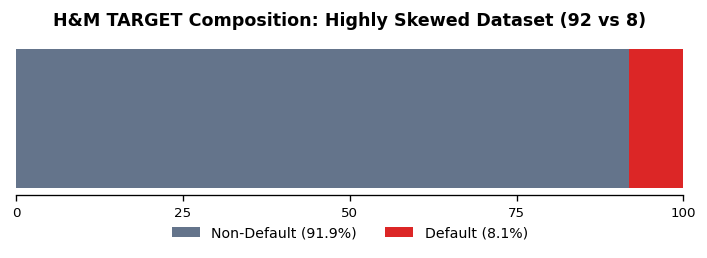

In [25]:
# Calculate Percentage
target_pct = application_train['TARGET'].value_counts(normalize=True) * 100

# Composition Data
non_default_pct = target_pct.loc[0]
default_pct = target_pct.loc[1]

fig, ax = plt.subplots(figsize=(6, 2.5), dpi=120)

# 100% Stacked Bar
ax.barh(0, non_default_pct, color='#64748B', label=f'Non-Default ({non_default_pct:.1f}%)')
ax.barh(0, default_pct, left=non_default_pct, color='#DC2626', label=f'Default ({default_pct:.1f}%)')

# Clean Bounds
ax.set_xlim(0, 100)
ax.set_yticks([]) 
ax.set_xticks([0, 25, 50, 75, 100])
ax.tick_params(axis='x', labelsize=8)
ax.spines[['top', 'right', 'left']].set_visible(False)

# Title & Layout
plt.title('H&M TARGET Composition: Highly Skewed Dataset (92 vs 8)', fontweight='bold', fontsize=10.5, pad=10)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.38), frameon=False, ncol=2, fontsize=8.5)

plt.tight_layout()
plt.show()

### 🎯 TARGET Variable: Baseline Portfolio Risk

* **Severe Class Imbalance:** The dataset is heavily skewed, with only **8.1%** of applicants classified as Defaulters (Target=1), while **91.9%** are Non-Defaulters.

> ### 💡 **Business Context**
> This 8.07% serves as our "Base Rate." In subsequent analyses, any customer segment exhibiting a default rate significantly higher than this baseline will be flagged as a high-risk zone.

> ### **Age Demographics**

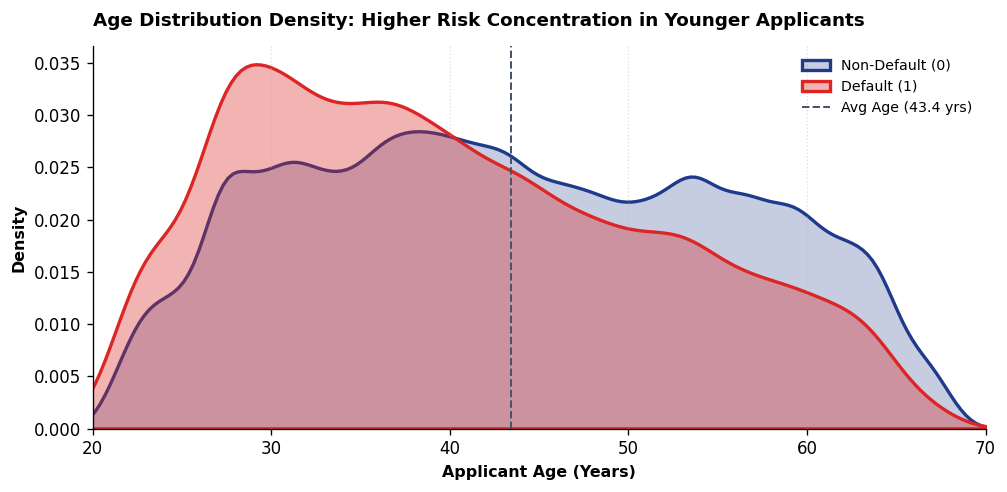

In [26]:
fig, ax = plt.subplots(figsize=(8.5, 4.2), dpi=120)

# KDE curves for Target 0 vs 1
sns.kdeplot(data=application_train[application_train['TARGET'] == 0]['AGE_IN_YEARS'], 
            label='Non-Default (0)', color='#1E3A8A', fill=True, alpha=0.25, lw=2, ax=ax)
sns.kdeplot(data=application_train[application_train['TARGET'] == 1]['AGE_IN_YEARS'], 
            label='Default (1)', color='#DC2626', fill=True, alpha=0.35, lw=2, ax=ax)

# Mean Age Benchmark Line
mean_age = application_train['AGE_IN_YEARS'].mean()
ax.axvline(mean_age, color='#475569', ls='--', lw=1.2, label=f'Avg Age ({mean_age:.1f} yrs)')

# Styling
ax.set_xlim(20, 70)
ax.set_xlabel('Applicant Age (Years)', fontweight='bold', fontsize=9.5)
ax.set_ylabel('Density', fontweight='bold', fontsize=9.5)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', ls=':', alpha=0.4)
ax.legend(frameon=False, loc='upper right', fontsize=8.5)

plt.title('Age Distribution Density: Higher Risk Concentration in Younger Applicants', 
          fontweight='bold', fontsize=11, loc='left', pad=12)
plt.tight_layout()
plt.show()

### 🧑‍🤝‍🧑 Age Demographics: The "Youth Penalty"

* **High-Risk Concentration:** The age density distribution reveals a severe spike in default probability among younger demographics. The default curve (red) peaks aggressively between **ages 25 and 35**.
* **Maturity & Stability:** As applicants cross the average age threshold (43.4 years), the non-default curve (blue) completely dominates. Older demographics prove to be statistically safer borrowers.

> ### **Employement Distribution**

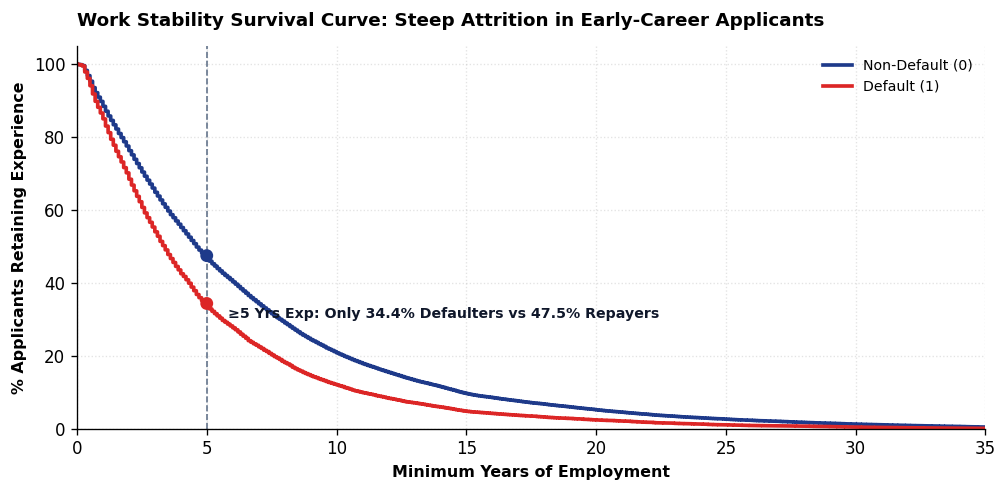

In [27]:
emp_0 = application_train[application_train['TARGET'] == 0][
    'YEARS_EMPLOYED'
].dropna()
emp_1 = application_train[application_train['TARGET'] == 1][
    'YEARS_EMPLOYED'
].dropna()

fig, ax = plt.subplots(figsize=(8.5, 4.2), dpi=120)

# Survival curves (1 - CDF)
x0, y0 = np.sort(emp_0), 100 * (1 - np.linspace(0, 1, len(emp_0)))
x1, y1 = np.sort(emp_1), 100 * (1 - np.linspace(0, 1, len(emp_1)))

ax.plot(x0, y0, label='Non-Default (0)', color='#1E3A8A', lw=2.2)
ax.plot(x1, y1, label='Default (1)', color='#DC2626', lw=2.2)

# Benchmark at 5 years
pct_0_5y = (emp_0 >= 5).mean() * 100
pct_1_5y = (emp_1 >= 5).mean() * 100

ax.axvline(5, color='#64748B', ls='--', lw=1)
ax.scatter(
    [5, 5],
    [pct_0_5y, pct_1_5y],
    color=['#1E3A8A', '#DC2626'],
    s=45,
    zorder=4,
)
ax.text(
    5.8,
    pct_1_5y - 4,
    f'≥5 Yrs Exp: Only {pct_1_5y:.1f}% Defaulters vs {pct_0_5y:.1f}% Repayers',
    fontsize=8.5,
    fontweight='bold',
    color='#0F172A',
)

ax.set_xlim(0, 35)
ax.set_ylim(0, 105)
ax.set_xlabel(
    'Minimum Years of Employment', fontweight='bold', fontsize=9.5
)
ax.set_ylabel(
    '% Applicants Retaining Experience', fontweight='bold', fontsize=9.5
)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='both', ls=':', alpha=0.35)
ax.legend(frameon=False, loc='upper right', fontsize=8.5)

plt.title(
    'Work Stability Survival Curve: Steep Attrition in Early-Career Applicants',
    fontweight='bold',
    fontsize=11,
    loc='left',
    pad=12,
)
plt.tight_layout()
plt.show()

### 🏢 Employment Tenure: The 5-Year Stability Threshold

* **The Danger Zone:** Defaulter density is heavily skewed toward early-career applicants, with risk sharply peaking before the 3-year employment mark. 
* **The Survival Gap:** At the 5-year employment milestone, a clear divergence occurs. **47.5%** of reliable repayers possess at least 5 years of experience, compared to only **34.4%** of defaulters. Job stability is a primary driver of credit reliability.

> ### 💡 **Strategic Action**
> Since most applicants are in their early-career stages with potentially lower job stability, the bank's income verification process (e.g., evaluating payslips and bank statements) must be strictly rigorous for this segment.

> ### **Income Source Demographics**

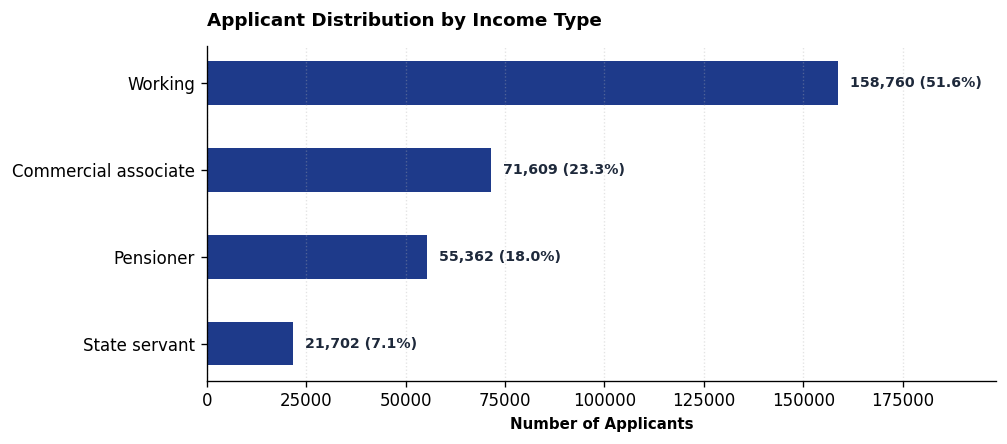

In [28]:
df = application_train['NAME_INCOME_TYPE'].value_counts().head(4).sort_values(ascending=True)
total = df.sum()

fig, ax = plt.subplots(figsize=(8.5, 3.8), dpi=120)

bars = ax.barh(df.index, df.values, color='#1E3A8A', height=0.5)

# Value Labels: Count + %
for bar in bars:
    w = bar.get_width()
    pct = (w / total) * 100
    ax.text(w + 3000, bar.get_y() + bar.get_height()/2, 
            f"{w:,.0f} ({pct:.1f}%)", 
            va='center', fontsize=8.5, fontweight='bold', color='#1E293B')

ax.set_xlim(0, df.max() * 1.25)
ax.set_xlabel('Number of Applicants', fontweight='bold', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', ls=':', alpha=0.35)

plt.title('Applicant Distribution by Income Type', fontweight='bold', fontsize=11, loc='left', pad=12)
plt.tight_layout()
plt.show()

### 💼 Income Source Demographics: The 'Working' Class Dependency

* **Portfolio Dominance:** Over half of the applicant base (**51.6%**, ~158k applicants) belongs to the standard 'Working' class, making them the primary revenue engine for the bank.
* **The Fixed-Income Segment:** 'Pensioners' form a surprisingly large secondary cohort (**18.0%**, ~55k applicants). This group represents a fundamentally different risk profile due to their fixed, non-scalable income streams.

> ### 💡 **Strategic Action**
> Bifurcate the underwriting funnel based on income elasticity. Implement aggressive, automated approvals for the 'Working' and 'Commercial Associate' cohorts (75% of volume), while deploying a specialized, fixed-income risk matrix for the 55k+ 'Pensioners'.

> ### **Gender Based Risk**

In [29]:
gender_risk = application_train.groupby('CODE_GENDER')["TARGET"].mean().reset_index()
gender_risk["DEFAULT_RISK_PRCTAGE"]  = gender_risk["TARGET"]*100
gender_risk

,CODE_GENDER,TARGET,DEFAULT_RISK_PRCTAGE
0,F,0.069956,6.995633
1,M,0.101437,10.143686


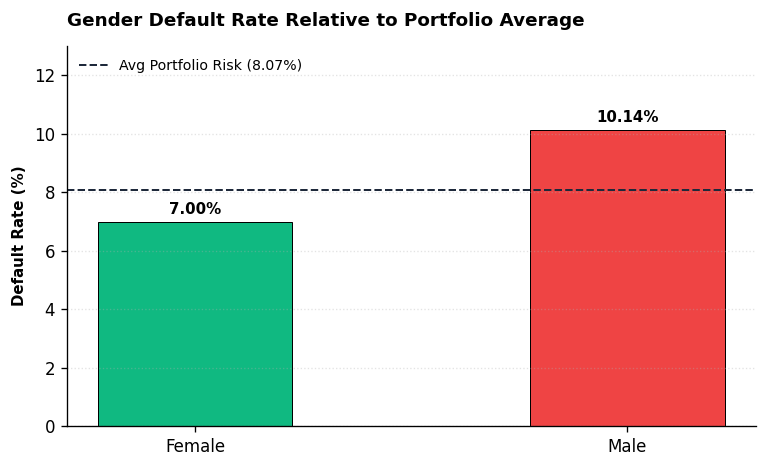

In [30]:
import matplotlib.pyplot as plt

df = gender_risk.copy()
labels = ['Female', 'Male']
rates = df['DEFAULT_RISK_PRCTAGE']
base_rate = 8.07

fig, ax = plt.subplots(figsize=(6.5, 4), dpi=120)

# Colors: Green for safer than avg, Red for higher risk
colors = ['#10B981', '#EF4444']
bars = ax.bar(labels, rates, color=colors, width=0.45, edgecolor='black', lw=0.6)

# Labels on top
ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=9, fontweight='bold')

# Portfolio Benchmark Reference
ax.axhline(base_rate, color='#1E293B', ls='--', lw=1.2, label=f'Avg Portfolio Risk ({base_rate}%)')

ax.set_ylabel('Default Rate (%)', fontweight='bold', fontsize=9)
ax.set_ylim(0, 13)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', ls=':', alpha=0.35)
ax.legend(frameon=False, loc='upper left', fontsize=8.5)

plt.title('Gender Default Rate Relative to Portfolio Average', fontweight='bold', fontsize=11, loc='left', pad=12)
plt.tight_layout()
plt.show()

### 🚻 Gender Risk Variance: The Male Default Premium

* **The Risk Outliers:** Male applicants exhibit a significantly higher propensity to default (**10.14%**), performing poorly compared to the overall portfolio baseline (**8.07%**).
* **The Safe Harbor:** Female applicants demonstrate vastly superior repayment reliability, operating well below the portfolio average at a **7.00%** default rate.

> ### 💡 **Business Context**
> Gender is a strong demographic indicator for risk. The underwriting team might need to look at secondary stabilizing factors (like job tenure or assets) more strictly when evaluating male applicants.

# **IMPORT SQLite3**

In [31]:
conn = sqlite3.connect("Credit_Default_Risk.db")

In [32]:
application_train.to_sql("application_train", conn, if_exists="replace", index=False)
prev_application.to_sql("prev_application", conn, if_exists="replace", index=False)

1670213

## Q1. What is the overall financial exposure and baseline default risk of the current loan portfolio?

In [33]:
kpi = """
    SELECT
        COUNT(SK_ID_CURR) as total_applicants,
        ROUND(AVG(TARGET) * 100, 2) AS default_rate_percentage,
        ROUND(SUM(AMT_CREDIT) / 1000000000, 2) AS total_credit_disbursed_billions,
        ROUND(SUM(CASE WHEN TARGET = 1 THEN AMT_CREDIT ELSE 0 END) / 1000000000, 2) AS total_amount_at_risk_billion
    FROM 
        application_train;
"""

kpi = pd.read_sql_query(kpi, conn)
kpi

,total_applicants,default_rate_percentage,total_credit_disbursed_billions,total_amount_at_risk_billion
0,307433,8.07,184.14,13.84


### 🌐 Portfolio Macro Overview: Baseline Metrics

* **Total Scale:** The dataset comprises **307,433** total applicants, representing a massive credit distribution pool.
* **Capital Disbursed:** Total credit deployed across the portfolio stands at **\$184.14 Billion**.
* **Portfolio Risk Baseline:** The overall default rate rests at **8.07%**, resulting in an aggregate capital loss exposure of **\$13.84 Billion**.

## Q2. How does physical asset ownership (Car vs. Real Estate) impact a borrower's likelihood to default?

In [34]:
assets = """
    SELECT
        CASE
            WHEN FLAG_OWN_CAR = 'Y' AND FLAG_OWN_REALTY = 'Y' THEN 'Owns Both Car + Realty'
            WHEN FLAG_OWN_CAR = 'N' AND FLAG_OWN_REALTY = 'Y' THEN 'Only Realty'
            WHEN FLAG_OWN_CAR = 'Y' AND FLAG_OWN_REALTY = 'N' THEN 'Only Car'
            ELSE 'Owns Neither'
        END AS assets_status,
        COUNT(SK_ID_CURR) AS total_applicants,
        SUM(TARGET) AS total_default,
        ROUND(AVG(TARGET) * 100, 2) AS default_rate_pct
        
    FROM 
        application_train
    GROUP BY 
        assets_status
    ORDER BY
        default_rate_pct DESC;
"""

assets = pd.read_sql_query(assets, conn)
assets

,assets_status,total_applicants,total_default,default_rate_pct
0,Owns Neither,61956,5570,8.99
1,Only Realty,140928,11671,8.28
2,Owns Both Car + Realty,72331,5302,7.33
3,Only Car,32218,2270,7.05


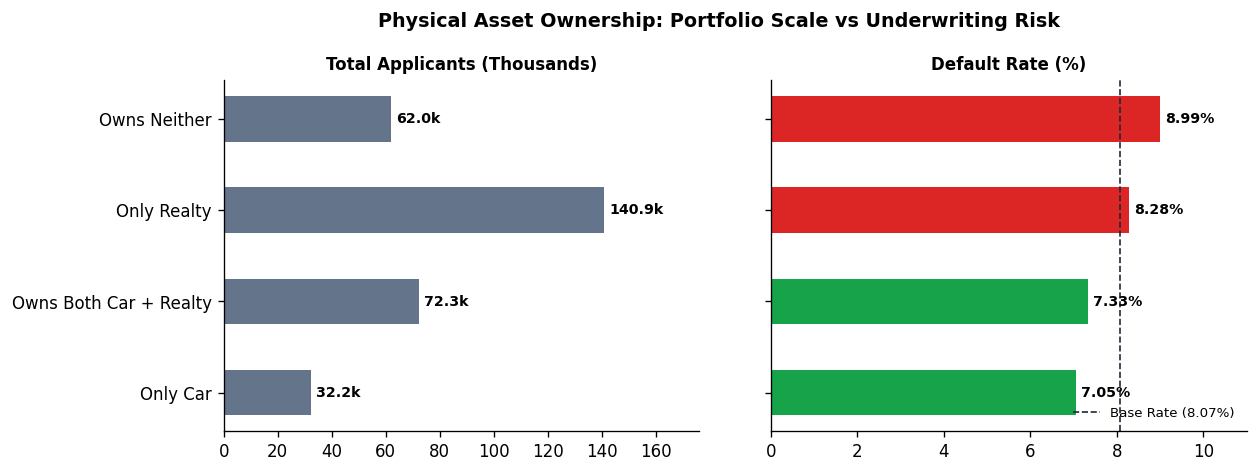

In [35]:
df = assets.sort_values('default_rate_pct', ascending=True).reset_index(drop=True)
base_rate = 8.07

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True, dpi=120, gridspec_kw={'wspace': 0.15})

# Left Panel: Applicant Distribution
b1 = ax1.barh(df['assets_status'], df['total_applicants'] / 1e3, color='#64748B', height=0.5)
ax1.bar_label(b1, fmt='%.1fk', padding=3, fontsize=8.5, fontweight='bold')
ax1.set_title('Total Applicants (Thousands)', fontweight='bold', fontsize=10)
ax1.set_xlim(0, (df['total_applicants'] / 1e3).max() * 1.25)
ax1.spines[['top', 'right']].set_visible(False)

# Right Panel: Default Rate %
colors = ['#16A34A' if r < base_rate else '#DC2626' for r in df['default_rate_pct']]
b2 = ax2.barh(df['assets_status'], df['default_rate_pct'], color=colors, height=0.5)
ax2.bar_label(b2, fmt='%.2f%%', padding=3, fontsize=8.5, fontweight='bold')
ax2.axvline(base_rate, color='#1E293B', ls='--', lw=1, label=f'Base Rate ({base_rate}%)')
ax2.set_title('Default Rate (%)', fontweight='bold', fontsize=10)
ax2.set_xlim(0, 11)
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(frameon=False, loc='lower right', fontsize=8)

plt.suptitle('Physical Asset Ownership: Portfolio Scale vs Underwriting Risk', fontweight='bold', fontsize=11.5, y=1.03)
plt.tight_layout()
plt.show()

### 🏡 Asset Ownership: The Collateral Cushion

* **The High-Risk Baseline:** Applicants who own absolutely no physical assets ("Owns Neither") represent a high-risk demographic, defaulting at an elevated rate of **8.99%**.
* **The Car Ownership Anomaly:** Surprisingly, owning "Only Realty" (8.28%) is riskier than the portfolio baseline. However, car ownership acts as a strong indicator of liquidity and financial health; applicants owning "Only Car" represent the safest cohort at **7.05%**.

> ### 💡 **Strategic Action**
> Revise collateral weighting in the underwriting model. Liquid assets (like vehicles) should be weighted higher than illiquid real estate for short-to-medium-term loans, as they demonstrate stronger immediate cash-flow stability.

## Q3. Is there a correlation between the number of dependents a client supports and their credit default risk?

In [36]:
children_count = """
    SELECT 
        CASE 
            WHEN CNT_CHILDREN = 0 THEN '0 Children'
            WHEN CNT_CHILDREN = 1 THEN '1 Children'
            WHEN CNT_CHILDREN = 2 THEN '2 Children'
            ELSE '3+ Children'
        END AS num_children,
        COUNT(SK_ID_CURR) AS total_applicants,
        SUM(TARGET) AS total_defaulters,
        ROUND(AVG(TARGET) * 100, 20) AS default_rate_pct
    FROM 
        application_train
    GROUP BY
        num_children
    ORDER BY 
        num_children;    
"""

children_count = pd.read_sql_query(children_count, conn)
children_count

,num_children,total_applicants,total_defaulters,default_rate_pct
0,0 Children,215317,16602,7.710492
1,1 Children,61105,5451,8.920710
2,2 Children,26739,2331,8.717604
3,3+ Children,4272,429,10.042135


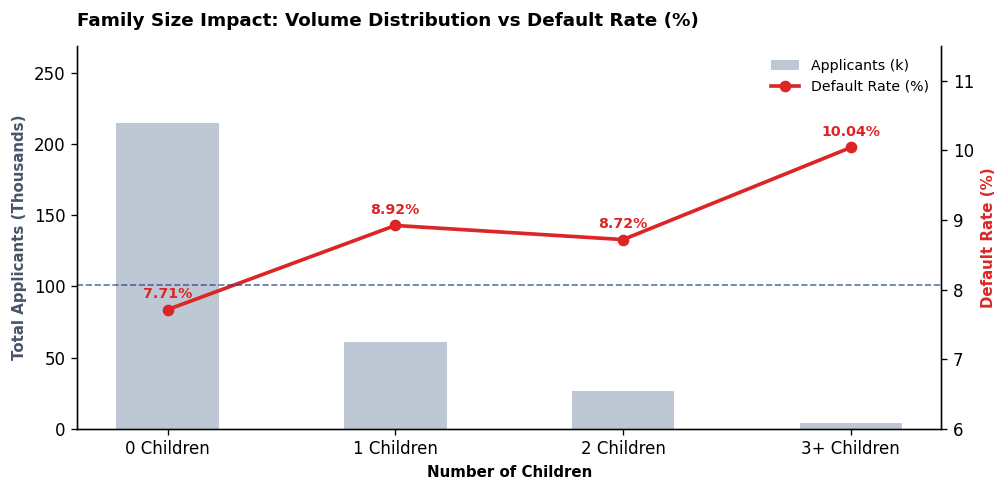

In [37]:
df = children_count

fig, ax1 = plt.subplots(figsize=(8.5, 4.2), dpi=120)

# Volume Bars (Background)
bars = ax1.bar(df['num_children'], df['total_applicants'] / 1e3, 
               color='#94A3B8', width=0.45, alpha=0.6, label='Applicants (k)')
ax1.set_ylabel('Total Applicants (Thousands)', fontweight='bold', color='#475569', fontsize=9)
ax1.set_ylim(0, (df['total_applicants'] / 1e3).max() * 1.25)
ax1.set_xlabel('Number of Children', fontweight='bold', fontsize=9)

# Default Rate Line (Foreground)
ax2 = ax1.twinx()
ax2.plot(df['num_children'], df['default_rate_pct'], 
         color='#DC2626', marker='o', lw=2.2, ms=6, label='Default Rate (%)')
ax2.axhline(8.07, color='#1E3A8A', ls='--', lw=1, alpha=0.7)

for i, val in enumerate(df['default_rate_pct']):
    ax2.annotate(f"{val:.2f}%", (i, val), textcoords="offset points", 
                 xytext=(0, 7), ha='center', fontsize=8.5, fontweight='bold', color='#DC2626')

ax2.set_ylabel('Default Rate (%)', fontweight='bold', color='#DC2626', fontsize=9)
ax2.set_ylim(6, 11.5)

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Combined Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=False, fontsize=8.5)

plt.title('Family Size Impact: Volume Distribution vs Default Rate (%)', 
          fontweight='bold', fontsize=11, loc='left', pad=12)
plt.tight_layout()
plt.show()

### 👨‍👩‍👧‍👦 Dependent Burden: Family Size Risk Scaling

* **The Safe Majority:** Applicants with **0 children** represent the vast majority of the portfolio volume (~215k applicants) and are the only demographic operating safely below the portfolio baseline at **7.71%**.
* **The Expense Penalty:** The moment an applicant has dependents, default risk spikes above the bank's average, culminating in a severe **10.04%** failure rate for large families (3+ children).

> ### 💡 **Strategic Action**
> Shift the underwriting focus from absolute 'Gross Income' to 'Estimated Disposable Income'. Implement a strict deduction formula for every stated dependent to calculate the true EMI affordability before loan approval.

## Q4. What are the primary drivers for historical loan rejections within the bank's underwriting process?

In [38]:
rejection_reason = """
    SELECT
        CODE_REJECT_REASON,
        (SELECT COUNT(*) FROM prev_application) AS total_applicants,
        COUNT(SK_ID_CURR) AS total_rejections,
        ROUND(COUNT(SK_ID_CURR) * 100.0 / (SELECT COUNT(*) FROM prev_application WHERE NAME_CONTRACT_STATUS = 'Refused'), 2) AS pct_total_rejection
    FROM 
        prev_application
    WHERE
        NAME_CONTRACT_STATUS = 'Refused'
    GROUP BY
        CODE_REJECT_REASON
    ORDER BY
        total_rejections DESC;
"""

rejection_reason = pd.read_sql_query(rejection_reason, conn)
rejection_reason

,CODE_REJECT_REASON,total_applicants,total_rejections,pct_total_rejection
0,HC,1670213,175231,60.28
1,LIMIT,1670213,55680,19.16
2,SCO,1670213,37467,12.89
3,SCOFR,1670213,12811,4.41
4,Unknown,1670213,5236,1.80
5,VERIF,1670213,3535,1.22
6,SYSTEM,1670213,717,0.25
7,Not Applicable,1670213,1,0.00


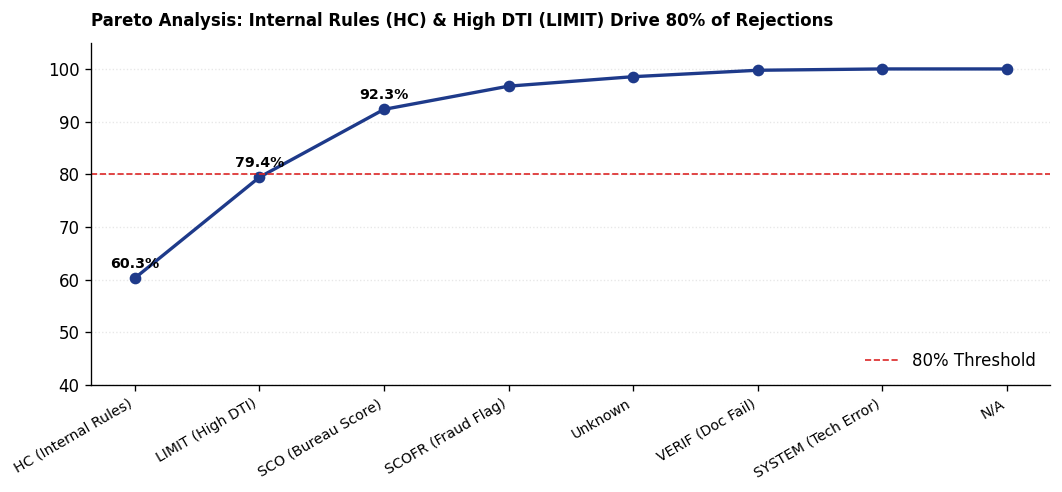

In [39]:
mapping = {'HC': 'HC (Internal Rules)', 'LIMIT': 'LIMIT (High DTI)', 'SCO': 'SCO (Bureau Score)',
           'SCOFR': 'SCOFR (Fraud Flag)', 'Unknown': 'Unknown', 'VERIF': 'VERIF (Doc Fail)', 
           'SYSTEM': 'SYSTEM (Tech Error)', 'Not Applicable': 'N/A'}

df = rejection_reason.sort_values('pct_total_rejection', ascending=False)
x = df['CODE_REJECT_REASON'].map(mapping).fillna(df['CODE_REJECT_REASON'])
y = df['pct_total_rejection'].cumsum()

fig, ax = plt.subplots(figsize=(9, 4.2), dpi=120)
ax.plot(x, y, color='#1E3A8A', marker='o', lw=2)
ax.axhline(80, color='#DC2626', ls='--', lw=1, label='80% Threshold')

for i, (xi, yi) in enumerate(zip(x, y)):
    if yi <= 95: ax.text(xi, yi + 2, f'{yi:.1f}%', ha='center', fontweight='bold', fontsize=8.5)

ax.set_xticklabels(x, rotation=30, ha='right', fontsize=8.5)
ax.set_ylim(40, 105)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', ls=':', alpha=0.3)
ax.legend(frameon=False, loc='lower right')
plt.title('Pareto Analysis: Internal Rules (HC) & High DTI (LIMIT) Drive 80% of Rejections', fontweight='bold', fontsize=10, loc='left', pad=10)
plt.tight_layout()
plt.show()

### 🚫 Underwriting Rejections: The 80/20 Bottleneck

* **Hyper-Concentration:** The loan rejection pipeline is not fragmented. A massive **60.3%** of all historical rejections are driven by a single code ('HC').
* **The Pareto Threshold:** Combining 'HC' with the second leading cause ('LIMIT' at 19.2%), exactly **79.4%** of all refused applications stem from just two underwriting criteria.

> ### 💡 **Strategic Action**
> Stop wasting resources investigating minor rejection categories. Conduct an immediate audit of the 'HC' (Hard Criteria) and 'LIMIT' rule engines. If 'LIMIT' indicates applicants requesting more than they qualify for, implement a dynamic "Pre-Approved Limit" slider on the initial application UI to drastically reduce the 19% rejection waste.

## **Q5. Does taking a loan significantly larger than one's annual income increase the likelihood of default?**

In [40]:
cr_to_incm_r = """
    SELECT
        CASE WHEN TARGET = 1 THEN 'Default (1)' ELSE 'Non-Default (0)' END AS loan_status,
        COUNT(SK_ID_CURR) AS total_applicants,
        ROUND(AVG(AMT_CREDIT * 1.0 / AMT_INCOME_TOTAL), 2) AS avg_credit_to_income_ratio
    FROM
        application_train
    GROUP BY
        TARGET
"""

cr_to_incm_r = pd.read_sql_query(cr_to_incm_r, conn)
cr_to_incm_r

,loan_status,total_applicants,avg_credit_to_income_ratio
0,Non-Default (0),282620,3.96
1,Default (1),24813,3.88


### ⚖️ Credit-to-Income Ratio: A Weak Predictor of Default

* **The Counter-Intuitive Reality:** The data invalidates the common assumption that higher debt-to-income ratios inherently drive defaults. Reliable repayers actually maintain a slightly *higher* average Credit-to-Income ratio (**3.96x**) compared to defaulters (**3.88x**).
* **Statistical Insignificance:** The marginal difference of 0.08 between the two cohorts proves that the raw size of the loan relative to declared income is not a primary driver of risk in this portfolio.

> ### 💡 **Strategic Action**
> Deprioritize the static 'Credit-to-Income' multiplier in the primary underwriting scorecard. Instead of focusing on how large the loan is compared to income, shift algorithmic weight toward behavioral and stability metrics (e.g., employment tenure, past refusal history, and family size).

## **Q6. Does the bank face higher risk from acquiring new clients or from lending to existing, proven clients?**

In [41]:
client_type  = """
    WITH past AS(
        SELECT
            SK_ID_CURR,
            NAME_CLIENT_TYPE,
            ROW_NUMBER() OVER(PARTITION BY SK_ID_CURR ORDER BY MONTHS_SINCE_DECISION DESC) AS r_n       -- Having duplicate rows (SK_ID_CURR) One to Many relation
        FROM 
            prev_application
    )

    SELECT 
        c.NAME_CLIENT_TYPE,
        COUNT(a.SK_ID_CURR) AS total_applicants,
        SUM(a.TARGET) AS total_defaulters,
        ROUND(AVG(a.TARGET) * 100, 2) AS default_rate_pct
    FROM 
        application_train a
    JOIN 
        past c ON a.SK_ID_CURR = c.SK_ID_CURR
    WHERE
        c.r_n  = 1                                                                                 -- select only one row if duplicate exist
        AND c.NAME_CLIENT_TYPE != 'Unknown'
    GROUP BY
        c.NAME_CLIENT_TYPE
    ORDER BY
        default_rate_pct DESC
"""

client_type = pd.read_sql_query(client_type, conn)
client_type

,NAME_CLIENT_TYPE,total_applicants,total_defaulters,default_rate_pct
0,New,236429,20680,8.75
1,Repeater,36141,2112,5.84
2,Refreshed,18412,1040,5.65


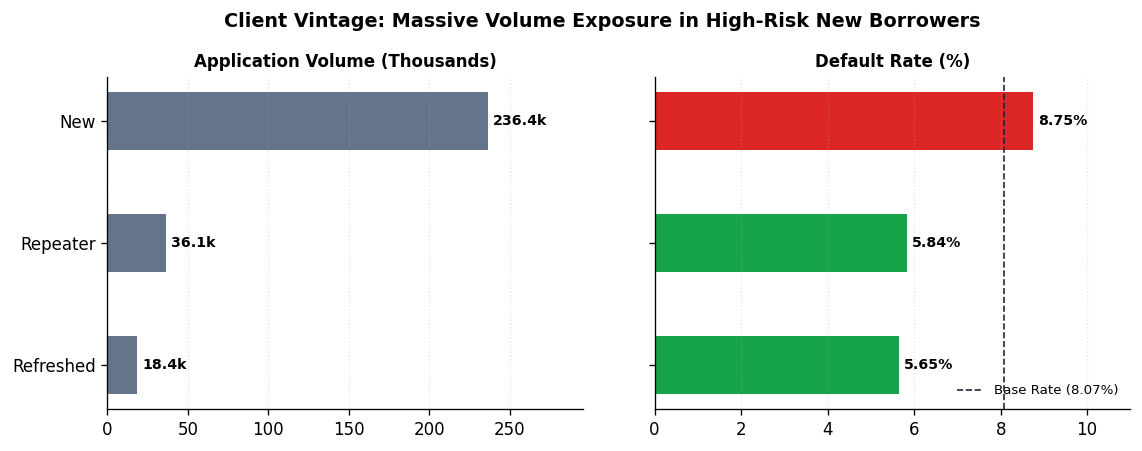

In [42]:
df = client_type.sort_values('default_rate_pct', ascending=True).reset_index(drop=True)
base_rate = 8.07

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True, dpi=120, gridspec_kw={'wspace': 0.15})

# Left: Total Application Volume
b1 = ax1.barh(df['NAME_CLIENT_TYPE'], df['total_applicants'] / 1e3, color='#64748B', height=0.48)
ax1.bar_label(b1, fmt='%.1fk', padding=3, fontsize=8.5, fontweight='bold')
ax1.set_title('Application Volume (Thousands)', fontweight='bold', fontsize=10)
ax1.set_xlim(0, (df['total_applicants'] / 1e3).max() * 1.25)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='x', ls=':', alpha=0.3)

# Right: Default Rate %
colors = ['#16A34A' if r < base_rate else '#DC2626' for r in df['default_rate_pct']]
b2 = ax2.barh(df['NAME_CLIENT_TYPE'], df['default_rate_pct'], color=colors, height=0.48)
ax2.bar_label(b2, fmt='%.2f%%', padding=3, fontsize=8.5, fontweight='bold')
ax2.axvline(base_rate, color='#1E293B', ls='--', lw=1, label=f'Base Rate ({base_rate}%)')
ax2.set_title('Default Rate (%)', fontweight='bold', fontsize=10)
ax2.set_xlim(0, 11)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='x', ls=':', alpha=0.3)
ax2.legend(frameon=False, loc='lower right', fontsize=8)

plt.suptitle('Client Vintage: Massive Volume Exposure in High-Risk New Borrowers', fontweight='bold', fontsize=11.5, y=1.03)
plt.tight_layout()
plt.show()

### 🔄 Client History: The "First-Time" Borrower Penalty

* **Unproven Risk Exposure:** 'New' clients are inherently riskier, exhibiting an **8.75%** default rate that breaches the portfolio baseline. More critically, the bank's capital exposure is heavily concentrated in this unverified cohort (~236k applications).
* **The Loyalty Advantage:** Existing clients ('Repeater' and 'Refreshed') prove significantly more reliable, operating at vastly safer default rates of **5.84%** and **5.65%**, respectively. Past successful interactions heavily dictate future repayment discipline.

> ### 💡 **Strategic Action**
> Deploy a "Trust-Tiered" approval funnel. Cap initial loan limits for all 'New' clients and route them through manual underwriting. Conversely, implement an automated, fast-track "VIP" approval system for 'Repeater' clients to maximize the retention of proven, safe borrowers.

## **Q7. Which education demographic is responsible for the largest absolute dollar loss in the bank's loan portfolio?**

In [43]:
edu_type_risk = """
    SELECT 
        NAME_EDUCATION_TYPE,
        COUNT(SK_ID_CURR) AS total_applicants,
        SUM(TARGET) AS total_defaulters,
        ROUND(SUM(CASE WHEN TARGET = 1 THEN AMT_CREDIT ELSE 0 END) / 1000000000, 2) AS total_money_lost_billions
    FROM
        application_train
    GROUP BY
        NAME_EDUCATION_TYPE
    ORDER BY
        total_money_lost_billions DESC;
"""

edu_type_risk = pd.read_sql_query(edu_type_risk, conn)
edu_type_risk

,NAME_EDUCATION_TYPE,total_applicants,total_defaulters,total_money_lost_billions
0,Secondary / secondary special,218358,19514,10.58
1,Higher education,74823,4008,2.59
2,Incomplete higher,10272,871,0.47
3,Lower secondary,3816,417,0.20
4,Academic degree,164,3,0.00


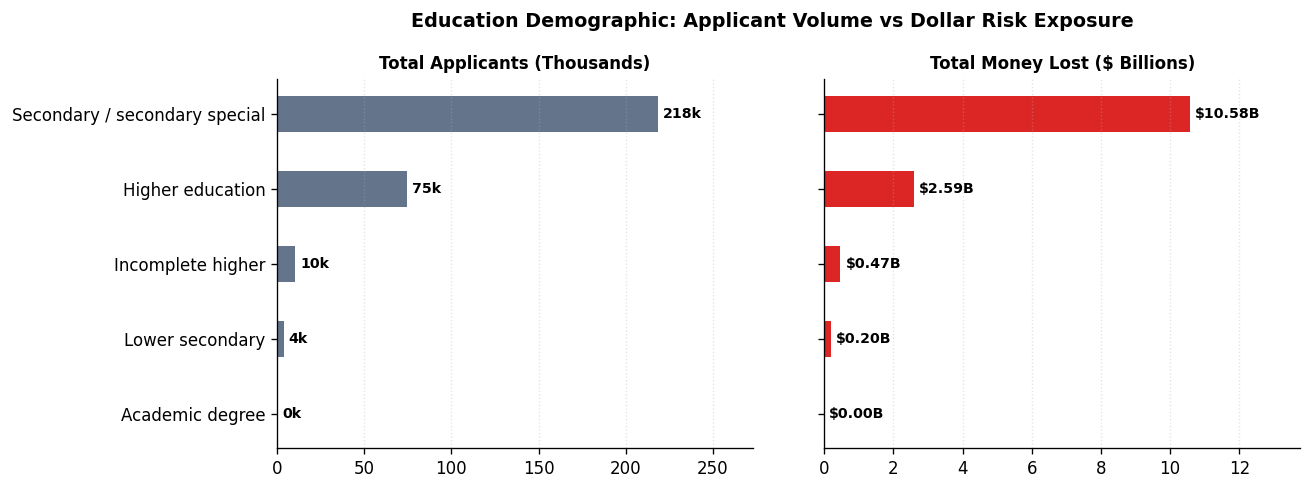

In [44]:
df = edu_type_risk.sort_values('total_money_lost_billions', ascending=True).reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), sharey=True, dpi=120, gridspec_kw={'wspace': 0.15})

# Left: Total Applicants
b1 = ax1.barh(df['NAME_EDUCATION_TYPE'], df['total_applicants'] / 1e3, color='#64748B', height=0.48)
ax1.bar_label(b1, fmt='%.0fk', padding=3, fontsize=8.5, fontweight='bold')
ax1.set_title('Total Applicants (Thousands)', fontweight='bold', fontsize=10)
ax1.set_xlim(0, (df['total_applicants'] / 1e3).max() * 1.25)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='x', ls=':', alpha=0.35)

# Right: Actual Capital Lost ($B)
b2 = ax2.barh(df['NAME_EDUCATION_TYPE'], df['total_money_lost_billions'], color='#DC2626', height=0.48)
ax2.bar_label(b2, fmt='$%.2fB', padding=3, fontsize=8.5, fontweight='bold')
ax2.set_title('Total Money Lost ($ Billions)', fontweight='bold', fontsize=10)
ax2.set_xlim(0, df['total_money_lost_billions'].max() * 1.3)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='x', ls=':', alpha=0.35)

plt.suptitle('Education Demographic: Applicant Volume vs Dollar Risk Exposure', fontweight='bold', fontsize=11.5, y=1.02)
plt.tight_layout()
plt.show()

### 🎓 Education Demographics: The $10.58 Billion Leakage

* **Massive Capital Drain:** The 'Secondary / secondary special' education cohort is the undisputed primary source of financial loss, independently accounting for an astonishing **$10.58 Billion** in defaulted loans.
* **The Volume Threat:** This demographic represents the core of the bank's business (218k applications). However, this high volume directly translates into unchecked, massive dollar-risk exposure compared to higher-educated cohorts.

> ### 💡 **Strategic Action**
> Immediately cap maximum loan-to-value (LTV) ratios for applicants with 'Secondary / secondary special' education. Implement stricter contract terms and potentially route these high-value applications through a secondary, manual risk-assessment committee to plug this critical capital leak.

## **Q8. How does an applicant's age demographic correlate with their likelihood to default, and do younger borrowers represent a disproportionately higher credit risk to the portfolio?**

In [45]:
conditions = [application_train['AGE_IN_YEARS'] < 25,
              application_train['AGE_IN_YEARS'] < 30,
              application_train['AGE_IN_YEARS'] < 35,
              application_train['AGE_IN_YEARS'] < 40,
              application_train['AGE_IN_YEARS'] < 45,
              application_train['AGE_IN_YEARS'] < 50,
              application_train['AGE_IN_YEARS'] < 55,
              application_train['AGE_IN_YEARS'] < 60,
              application_train['AGE_IN_YEARS'] < 65]

choices = ['20-25', '25-30', '30-35', '35-40', '40-45', '45-50', '50-55', '55-60', '60-65']

application_train['age_group'] = np.select(conditions, choices, default='65+')
age_risk_df = application_train.groupby('age_group')['TARGET'].agg(['count', 'sum', 'mean']).reset_index()

age_risk_df.rename(columns={'count': 'total_applicants',
                            'sum': 'total_defaulters',
                            'mean': 'default_rate_pct'}, inplace=True)

age_risk_df['default_rate_pct'] = (age_risk_df['default_rate_pct'] * 100).round(2)

age_risk_df

,age_group,total_applicants,total_defaulters,default_rate_pct
0,20-25,12146,1495,12.31
1,25-30,32839,3659,11.14
2,30-35,39428,4054,10.28
3,35-40,42849,3825,8.93
4,40-45,41405,3255,7.86
5,45-50,35120,2603,7.41
6,50-55,34927,2341,6.70
7,55-60,33129,1832,5.53
8,60-65,27468,1447,5.27
9,65+,8122,302,3.72


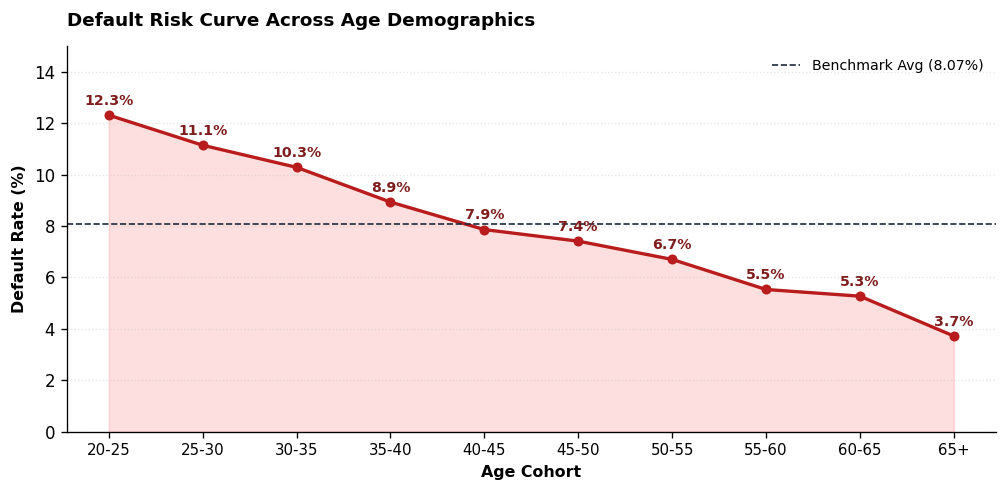

In [46]:
fig, ax = plt.subplots(figsize=(8.5, 4.2), dpi=120)

x = age_risk_df['age_group']
y = age_risk_df['default_rate_pct']

# Line + Shaded Area
ax.plot(x, y, color='#B91C1C', lw=2, marker='o', ms=5)
ax.fill_between(range(len(x)), y, color='#FCA5A5', alpha=0.35)

# Benchmark line
ax.axhline(8.07, color='#1E293B', ls='--', lw=1, label='Benchmark Avg (8.07%)')

# Clean Markers Labels
for i, val in enumerate(y):
    ax.text(i, val + 0.4, f"{val:.1f}%", ha='center', fontsize=8.5, fontweight='bold', color='#7F1D1D')

ax.set_ylim(0, 15)
ax.set_xticks(range(len(x)))
ax.set_xticklabels(x, fontsize=9)
ax.set_xlabel('Age Cohort', fontweight='bold', fontsize=9.5)
ax.set_ylabel('Default Rate (%)', fontweight='bold', fontsize=9.5)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', ls=':', alpha=0.3)
ax.legend(frameon=False, loc='upper right', fontsize=8.5)

plt.title('Default Risk Curve Across Age Demographics', fontweight='bold', fontsize=11, loc='left', pad=12)
plt.tight_layout()
plt.show()

### 📉 Age Cohorts: The Volume vs. Vulnerability Matrix

* **The Linear Risk Decline:** Default probability is perfectly inversely correlated with age. The risk drops strictly and linearly from a peak of **12.3%** in the 20-25 cohort down to **3.7%** for the 65+ cohort.
* **The High-Exposure Zone:** While the youngest group is the riskiest, the true threat to the portfolio lies in the **25-35 age bracket**. This demographic combines severe default rates (10.3% - 11.1%) with massive applicant volume (~72,000 applicants), maximizing capital exposure.

> ### 💡 **Strategic Action**
> Implement a graduated risk-premium model. Interest rates and collateral requirements must be heavily front-loaded for applicants under 35 to offset their systemic volatility. As applicants age past the 40-year threshold (dropping below the 8.07% baseline), auto-qualify them for prime lending rates.

## **Q9. Do occupations with the highest EMI burden strictly correlate with the highest default rates?**

In [47]:
EMI_burden = """
    SELECT
        OCCUPATION_TYPE,
        COUNT(SK_ID_CURR) AS total_applicants,
        ROUND(AVG((AMT_ANNUITY * 100.0) / AMT_INCOME_TOTAL), 2) AS avg_EMI_burden_pct,
        ROUND(AVG(TARGET) * 100, 2) AS default_rate_pct
    FROM
        application_train
    GROUP BY
        OCCUPATION_TYPE
    ORDER BY
        avg_EMI_burden_pct DESC;
"""

EMI_burden = pd.read_sql_query(EMI_burden,conn)
EMI_burden

,OCCUPATION_TYPE,total_applicants,avg_EMI_burden_pct,default_rate_pct
0,Cooking staff,5946,19.82,10.44
1,Cleaning staff,4653,19.41,9.61
2,Medicine staff,8537,19.13,6.70
3,Secretaries,1305,19.06,7.05
4,Unknown,96355,18.90,6.51
5,Sales staff,32102,18.83,9.63
6,Low-skill Laborers,2090,18.65,17.18
7,Security staff,6721,18.44,10.74
8,Waiters/barmen staff,1347,18.32,11.28
9,Core staff,27561,17.84,6.30


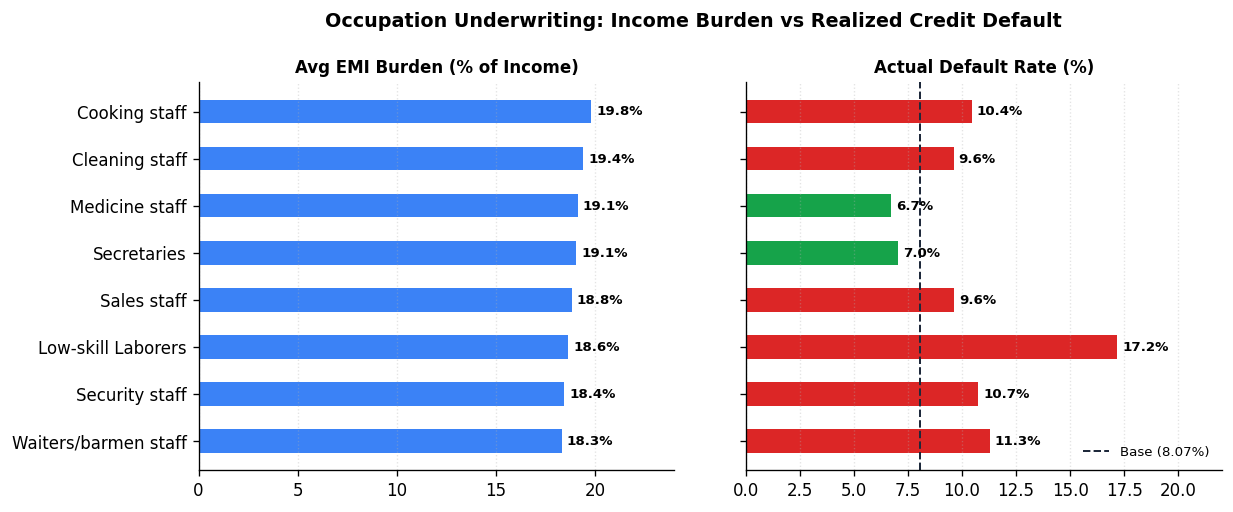

In [48]:
df = EMI_burden[EMI_burden['OCCUPATION_TYPE'] != 'Unknown'].head(8).sort_values('avg_EMI_burden_pct', ascending=True).reset_index(drop=True)
base_rate = 8.07

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True, dpi=120, gridspec_kw={'wspace': 0.15})

# Left: EMI Burden %
b1 = ax1.barh(df['OCCUPATION_TYPE'], df['avg_EMI_burden_pct'], color='#3B82F6', height=0.5)
ax1.bar_label(b1, fmt='%.1f%%', padding=3, fontsize=8, fontweight='bold')
ax1.set_title('Avg EMI Burden (% of Income)', fontweight='bold', fontsize=10)
ax1.set_xlim(0, 24)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='x', ls=':', alpha=0.35)

# Right: Actual Default Risk %
colors = ['#16A34A' if r < base_rate else '#DC2626' for r in df['default_rate_pct']]
b2 = ax2.barh(df['OCCUPATION_TYPE'], df['default_rate_pct'], color=colors, height=0.5)
ax2.bar_label(b2, fmt='%.1f%%', padding=3, fontsize=8, fontweight='bold')
ax2.axvline(base_rate, color='#1E293B', ls='--', lw=1.2, label=f'Base ({base_rate}%)')
ax2.set_title('Actual Default Rate (%)', fontweight='bold', fontsize=10)
ax2.set_xlim(0, 22)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='x', ls=':', alpha=0.35)
ax2.legend(frameon=False, loc='lower right', fontsize=8)

plt.suptitle('Occupation Underwriting: Income Burden vs Realized Credit Default', fontweight='bold', fontsize=11.5, y=1.02)
plt.tight_layout()
plt.show()

### 🛠️ Occupation & Affordability: The EMI Burden Disconnect

* **Stability Overrides Math:** High EMI-to-Income ratios do not universally predict default. For example, 'Medicine staff' carry a severe 19.1% EMI burden but maintain a highly secure 6.7% default rate.
* **The Vulnerability Peak:** 'Low-skill Laborers' represent the portfolio's absolute peak risk at a **17.2%** default rate, despite carrying a slightly lower average EMI burden (18.6%) than top categories. 

> ### 💡 **Strategic Action**
> Abandon universal EMI-to-Income limits. Implement occupation-based EMI capping. Highly stable professions (Medicine, Secretaries) can safely be approved for EMIs consuming up to 20% of their income. Conversely, volatile or low-skill roles must be strictly capped at a 10-12% EMI threshold to absorb income shocks.

## **Q10. Does the stated intent of a previously requested cash loan (e.g., "Urgent needs" vs. "Housing") serve as a reliable predictor for an applicant's current default risk?**

In [49]:
query = """
    WITH past_purpose AS (
        SELECT 
            SK_ID_CURR,
            NAME_CASH_LOAN_PURPOSE,
            ROW_NUMBER() OVER(PARTITION BY SK_ID_CURR ORDER BY MONTHS_SINCE_DECISION DESC) AS r_n
        FROM 
            prev_application
        WHERE
            NAME_CASH_LOAN_PURPOSE NOT IN ('XAP', 'XNA')
    )
    SELECT
        p.NAME_CASH_LOAN_PURPOSE,
        COUNT(a.SK_ID_CURR) AS total_application,
        ROUND(AVG(a.TARGET) * 100, 2) AS default_rate_pct
    FROM 
        application_train a
    JOIN past_purpose p ON a.SK_ID_CURR = p.SK_ID_CURR
    WHERE
        p.r_n = 1
    GROUP BY
        p.NAME_CASH_LOAN_PURPOSE
    HAVING
        total_application > 500
    ORDER BY
        default_rate_pct DESC
"""

query_df = pd.read_sql_query(query, conn)
query_df

,NAME_CASH_LOAN_PURPOSE,total_application,default_rate_pct
0,Urgent needs,1049,13.92
1,Housing Related,2748,12.34
2,Other,1655,11.90
3,Not Applicable (Non-Cash),265424,8.10
4,Purpose Not Recorded,18152,7.96


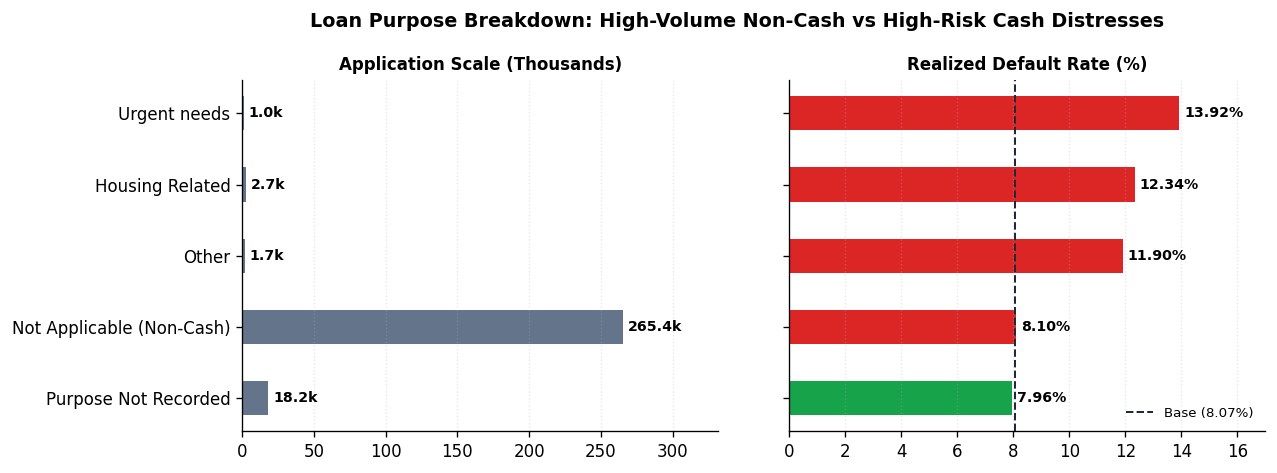

In [50]:
df = query_df.sort_values('default_rate_pct', ascending=True).reset_index(drop=True)
col_name = 'NAME_CASH_LOAD_PURPOSE' if 'NAME_CASH_LOAD_PURPOSE' in df else 'NAME_CASH_LOAN_PURPOSE'
base_rate = 8.07

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True, dpi=120, gridspec_kw={'wspace': 0.15})

# Left: Application Volume (Thousands)
b1 = ax1.barh(df[col_name], df['total_application'] / 1e3, color='#64748B', height=0.48)
ax1.bar_label(b1, fmt='%.1fk', padding=3, fontsize=8.5, fontweight='bold')
ax1.set_title('Application Scale (Thousands)', fontweight='bold', fontsize=10)
ax1.set_xlim(0, (df['total_application'] / 1e3).max() * 1.25)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='x', ls=':', alpha=0.3)

# Right: Default Rate %
colors = ['#16A34A' if r <= base_rate else '#DC2626' for r in df['default_rate_pct']]
b2 = ax2.barh(df[col_name], df['default_rate_pct'], color=colors, height=0.48)
ax2.bar_label(b2, fmt='%.2f%%', padding=3, fontsize=8.5, fontweight='bold')
ax2.axvline(base_rate, color='#1E293B', ls='--', lw=1.2, label=f'Base ({base_rate}%)')
ax2.set_title('Realized Default Rate (%)', fontweight='bold', fontsize=10)
ax2.set_xlim(0, 17)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='x', ls=':', alpha=0.3)
ax2.legend(frameon=False, loc='lower right', fontsize=8)

plt.suptitle('Loan Purpose Breakdown: High-Volume Non-Cash vs High-Risk Cash Distresses', 
             fontweight='bold', fontsize=11.5, y=1.03)
plt.tight_layout()
plt.show()

### 🚨 Loan Intent: The "Urgent Needs" Distress Signal

* **The Desperation Penalty:** Cash loans requested specifically for 'Urgent needs' act as a severe financial distress signal, carrying a catastrophic portfolio-leading default rate of **13.92%**. 
* **Systemic Stability:** Despite the extreme risk of cash-intent loans, the bank's systemic exposure is highly insulated. Over **94% of the portfolio volume** (265.4k apps) is tied to 'Non-Cash' intents, which perform safely at the 8.10% baseline.

> ### 💡 **Strategic Action**
> Do not auto-reject 'Urgent needs' loans, but remove them from the automated approval pipeline. Since the volume is incredibly low (~1,000 applications), routing these specific cases to a manual underwriting desk for strict income-verification will intercept the highest-risk defaults without slowing down the core business.

## **Q11. How does the recency of a prior loan rejection—specifically whether it occurred within the last 12 months—influence an applicant's current likelihood to default?**

In [51]:
rejection_time = """
    WITH reject_timeline AS(
        SELECT 
            SK_ID_CURR,
            CASE
                WHEN MONTHS_SINCE_DECISION <= 12 THEN 'Recent Rejection (<= 1 year)'
                ELSE 'Old Rejection (> 1 year)'
            END AS rejection_timeline,
            ROW_NUMBER() OVER(PARTITION BY SK_ID_CURR ORDER BY MONTHS_SINCE_DECISION ASC) AS r_n
        FROM 
            prev_application
        WHERE 
            NAME_CONTRACT_STATUS = 'Refused'
    )

    SELECT 
        r.rejection_timeline,
        COUNT(a.SK_ID_CURR) AS total_applicants,
        ROUND(AVG(a.TARGET) * 100, 2) AS default_rate_pct
    FROM 
        application_train a
    JOIN 
        reject_timeline r
        ON a.SK_ID_CURR = r.SK_ID_CURR
    WHERE
        r.r_n = 1
    GROUP BY
        r.rejection_timeline
    ORDER BY
        default_rate_pct DESC;
"""

rejection_time = pd.read_sql_query(rejection_time, conn)
rejection_time

,rejection_timeline,total_applicants,default_rate_pct
0,Recent Rejection (<= 1 year),49511,11.88
1,Old Rejection (> 1 year),50758,8.79


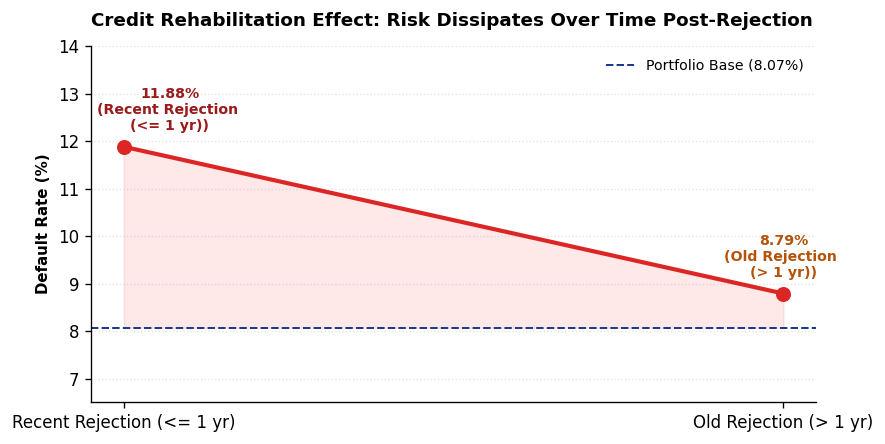

In [52]:
df = rejection_time.sort_values('rejection_timeline', ascending=False)
categories = ['Recent Rejection (<= 1 yr)', 'Old Rejection (> 1 yr)']
rates = [11.88, 8.79]

fig, ax = plt.subplots(figsize=(7.5, 3.8), dpi=120)

# Trajectory Slope Line
ax.plot(categories, rates, color='#DC2626', marker='o', lw=2.5, ms=8)
ax.axhline(8.07, color='#1E3A8A', ls='--', lw=1.2, label='Portfolio Base (8.07%)')

# Shaded spread to baseline
ax.fill_between(categories, rates, 8.07, color='#FCA5A5', alpha=0.25)

# Value Labels
ax.text(0.07, 11.88 + 0.35, "11.88%\n(Recent Rejection \n(<= 1 yr))", ha='center', fontweight='bold', fontsize=8.5, color='#991B1B')
ax.text(1, 8.79 + 0.35, "8.79%\n(Old Rejection \n(> 1 yr))", ha='center', fontweight='bold', fontsize=8.5, color='#B45309')

ax.set_ylim(6.5, 14)
ax.set_ylabel('Default Rate (%)', fontweight='bold', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', ls=':', alpha=0.35)
ax.legend(frameon=False, loc='upper right', fontsize=8.5)

plt.title('Credit Rehabilitation Effect: Risk Dissipates Over Time Post-Rejection', 
          fontweight='bold', fontsize=11, loc='left', pad=12)
plt.tight_layout()
plt.show()

### ⏳ Post-Rejection Timeline: The 12-Month "Cooling-Off" Period

* **Immediate Recidivism Risk:** Applicants who re-apply within one year of a previous rejection ("Recent Rejection") carry a highly toxic default rate of **11.88%**, indicating unresolved financial distress.
* **The Rehabilitation Effect:** As the time since the last rejection extends beyond one year ("Old Rejection"), the default rate sharply dissipates to **8.79%**, approaching the standard portfolio baseline (8.07%). 

> ### 💡 **Strategic Action**
> Hardcode a strict "12-Month Cooling-Off" lock in the automated underwriting system. Any applicant with a recorded rejection within the trailing 365 days should be automatically declined or routed to a high-interest subprime tier, as their fundamental financial instability has not had sufficient time to recover.

## **Q12. Which occupational demographics drive the highest aggregate capital loss for the portfolio, and how does that macro exposure contrast with the average per-defaulter severity?**

In [53]:
query_occ = """
    SELECT 
        OCCUPATION_TYPE,
        COUNT(SK_ID_CURR) AS total_applicants,
        SUM(TARGET) AS total_defaulters,
        ROUND(SUM(CASE WHEN TARGET = 1 THEN AMT_CREDIT ELSE 0 END) / 1000000000, 2) AS total_money_lost_billions,
        ROUND(SUM(CASE WHEN TARGET = 1 THEN AMT_CREDIT ELSE 0 END) / NULLIF(SUM(TARGET), 0), 2) AS avg_money_lost_per_defaulter
    FROM 
        application_train
    WHERE
        OCCUPATION_TYPE != 'Unknown'
    GROUP BY 
        OCCUPATION_TYPE
    ORDER BY 
        total_money_lost_billions DESC;
"""

query_occ = pd.read_sql_query(query_occ, conn)
query_occ

,OCCUPATION_TYPE,total_applicants,total_defaulters,total_money_lost_billions,avg_money_lost_per_defaulter
0,Laborers,55177,5836,3.11,532780.83
1,Sales staff,32102,3092,1.67,541232.43
2,Drivers,18602,2107,1.19,562645.29
3,Core staff,27561,1737,1.01,581342.86
4,Managers,21355,1328,0.94,704124.57
5,High skill tech staff,11380,701,0.42,596004.30
6,Security staff,6721,722,0.38,520072.31
7,Medicine staff,8537,572,0.31,548255.56
8,Cooking staff,5946,621,0.31,501909.62
9,Accountants,9811,474,0.31,663798.37


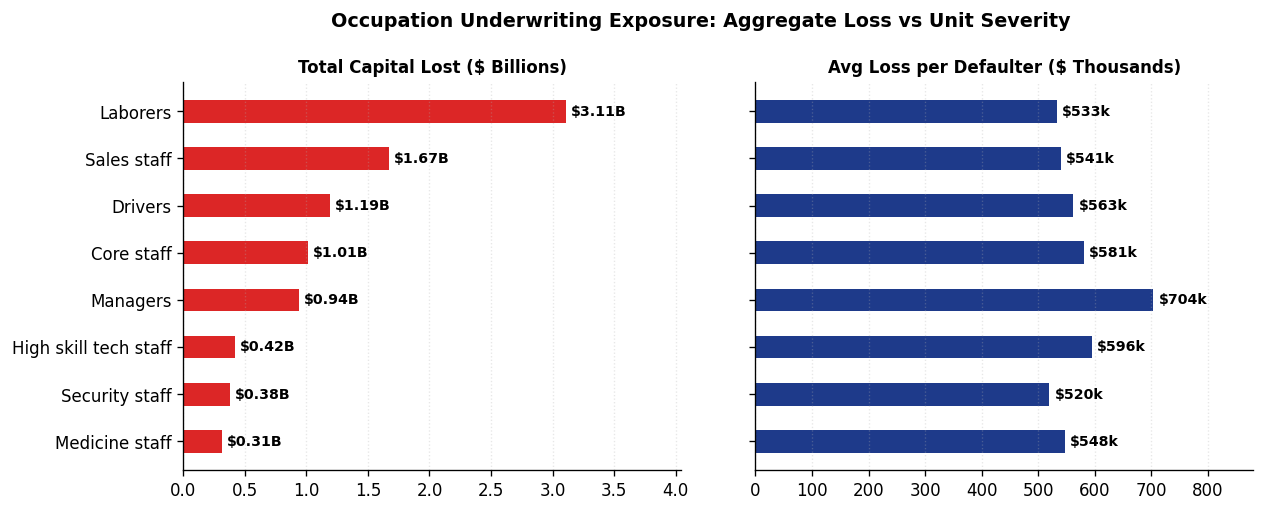

In [54]:
df = query_occ.head(8).sort_values('total_money_lost_billions', ascending=True).reset_index(drop=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True, dpi=120, gridspec_kw={'wspace': 0.15})

# Left: Total Loss ($B)
b1 = ax1.barh(df['OCCUPATION_TYPE'], df['total_money_lost_billions'], color='#DC2626', height=0.48)
ax1.bar_label(b1, fmt='$%.2fB', padding=3, fontsize=8.5, fontweight='bold')
ax1.set_title('Total Capital Lost ($ Billions)', fontweight='bold', fontsize=10)
ax1.set_xlim(0, df['total_money_lost_billions'].max() * 1.3)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='x', ls=':', alpha=0.3)

# Right: Avg Loss per Defaulter ($k)
b2 = ax2.barh(df['OCCUPATION_TYPE'], df['avg_money_lost_per_defaulter'] / 1e3, color='#1E3A8A', height=0.48)
ax2.bar_label(b2, fmt='$%.0fk', padding=3, fontsize=8.5, fontweight='bold')
ax2.set_title('Avg Loss per Defaulter ($ Thousands)', fontweight='bold', fontsize=10)
ax2.set_xlim(0, (df['avg_money_lost_per_defaulter'] / 1e3).max() * 1.25)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(axis='x', ls=':', alpha=0.3)

plt.suptitle('Occupation Underwriting Exposure: Aggregate Loss vs Unit Severity', fontweight='bold', fontsize=11.5, y=1.02)
plt.tight_layout()
plt.show()

### 💼 Occupational Capital Loss: Aggregate Exposure vs. Unit Severity

* **The Macro Drain (Volume Risk):** The 'Laborers' demographic is the largest systemic liability. Due to sheer applicant volume and high default frequencies, they have wiped out **\$3.11 Billion** in total bank capital, dwarfing all other professions.
* **The Micro Threat (Severity Risk):** While 'Managers' account for a smaller total aggregate loss (**\$0.94B**), they possess the highest *unit severity*. A single defaulting manager costs the bank an average of **\$704k**, highlighting the danger of high-ticket loan approvals.

> ### 💡 **Strategic Action**
> Deploy a two-pronged risk mitigation framework. For 'Laborers', implement strict, automated Loan-to-Value (LTV) caps across the board to stem the systemic macro bleeding. For 'Managers', mandate deep-dive manual asset and collateral verification, as their massive individual ticket sizes carry catastrophic per-unit risk.

## **Q13. How does a history of previous loan refusals impact a borrower's current likelihood to default?**

In [55]:
past_refusal = """
    WITH prev_refusal_flag AS (
        SELECT 
            SK_ID_CURR,
            MAX(CASE WHEN NAME_CONTRACT_STATUS = 'Refused' THEN 1 ELSE 0 END) AS has_refused
        FROM 
            prev_application
        GROUP BY
            SK_ID_CURR
    )
    SELECT
        CASE WHEN p.has_refused = 1 THEN 'Past Loan Refused' ELSE 'No Past Refused' END AS refusal_status,
        COUNT(a.SK_ID_CURR) as total_applicants,
        SUM(a.TARGET) AS total_defaulters,
        ROUND((CAST(SUM(a.TARGET) AS FLOAT) / COUNT(a.SK_ID_CURR)) * 100, 2) AS default_rate_pct
    FROM 
        application_train a
    LEFT JOIN
        prev_refusal_flag p 
        ON a.SK_ID_CURR = p.SK_ID_CURR
    GROUP BY
        refusal_status;
"""

past_refusal = pd.read_sql_query(past_refusal, conn)
past_refusal

,refusal_status,total_applicants,total_defaulters,default_rate_pct
0,No Past Refused,207164,14469,6.98
1,Past Loan Refused,100269,10344,10.32


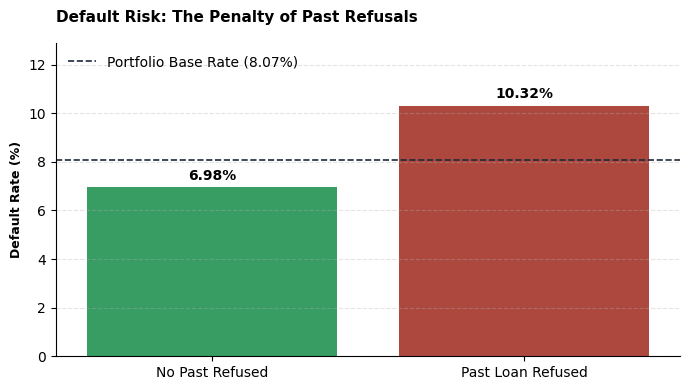

In [56]:
plt.figure(figsize=(7, 4))

# Green for safe (No Past Refused), Red for danger (Past Loan Refused)
custom_colors = ['#27AE60', '#C0392B']

ax = sns.barplot(
    data=past_refusal,
    x="refusal_status",
    y="default_rate_pct",
    palette=custom_colors
)

# Bar ke upar percentages likhne ke liye
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3, fontweight="bold")

# Portfolio Baseline (8.07%)
baseline = 8.07
ax.axhline(baseline, color='#1E293B', ls='--', lw=1.2, label=f'Portfolio Base Rate ({baseline}%)')

# Formatting & Aesthetics
plt.title('Default Risk: The Penalty of Past Refusals', fontweight='bold', fontsize=11, loc='left', pad=15)
plt.ylabel('Default Rate (%)', fontweight='bold', fontsize=9)
plt.xlabel('') # X-axis title hide kiya for clean look
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.35)

# Y-axis ko thoda lamba karna taaki labels cut na ho
plt.ylim(0, past_refusal["default_rate_pct"].max() * 1.25)

plt.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

### 🛑 The Refusal Stigma: Predictive Power of Past Denials

* **The Clean Slate Advantage:** Applicants with an unblemished history ("No Past Refused") form the ultra-safe core of the portfolio, operating well below the baseline at a **6.98%** default rate (across ~207k applications).
* **The Recidivism Reality:** A previous loan refusal acts as a massive red flag. Applicants who were previously denied default at a severe **10.32%** rate. With over 100k applicants falling into this bucket, this represents a major systemic vulnerability.

> ### 💡 **Strategic Action**
> Introduce a "Refusal Penalty" in the automated credit-scoring model. Any applicant with a prior refusal flag should automatically require a 15-20% higher down payment or collateral value to offset their statistically proven 10.32% failure risk.

# 🎯 Final Executive Recommendations
---
> ### 1. **Enforce a 12-Month Cooling-Off Period:**
> Applicants with a prior loan refusal default at a severe **10.32%** rate across 100k+ volume. Hardcode an automated restriction requiring a minimum 12-month gap post-rejection before re-applying to filter out active financial distress.

> ### 2. **Ring-Fence High-Risk Demographics:**
> Younger applicants (25–35 age bracket, **10.3%–11.1%** default rate) and early-career professionals (<3 years tenure) drive systemic exposure. Implement stricter collateral requirements and front-loaded interest rates for these cohorts.

> ### 3. **Deploy Occupation-Based EMI Capping:**
> Abandon universal debt-to-income limits. High-stability professions (Medicine staff at **6.7%** default) can sustain higher leverage, whereas volatile low-skill labor sectors (**17.2%** default) require strict EMI caps capped at 10-12% of net income.

> ### 4. **Fast-Track Repeat and Asset-Backed Borrowers:**
> Leverage the loyalty advantage of existing clients (**5.84%** default for repeaters) and the liquidity strength of car owners (**7.05%** default). Streamline automated VIP approvals for these segments while throttling unverified new-to-bank applicants.

> ### 5. **Mitigate Macro Loss Concentration:**
> The 'Secondary Education' demographic alone accounts for **\$10.58 Billion** in credit leakage, while 'Laborers' represent **\$3.11 Billion** in aggregate capital loss. Enforce mandatory manual risk committees for high-volume, high-loss tiers to plug portfolio bleeding.